# 1. Rassembler et charger les données

=== Description statistique ===
       X1 transaction date  X2 house age  \
count           414.000000    414.000000   
mean           2013.148971     17.712560   
std               0.281967     11.392485   
min            2012.667000      0.000000   
25%            2012.917000      9.025000   
50%            2013.167000     16.100000   
75%            2013.417000     28.150000   
max            2013.583000     43.800000   

       X3 distance to the nearest MRT station  \
count                              414.000000   
mean                              1083.885689   
std                               1262.109595   
min                                 23.382840   
25%                                289.324800   
50%                                492.231300   
75%                               1454.279000   
max                               6488.021000   

       X4 number of convenience stores  X5 latitude  X6 longitude  \
count                       414.000000   414.000000    414.0

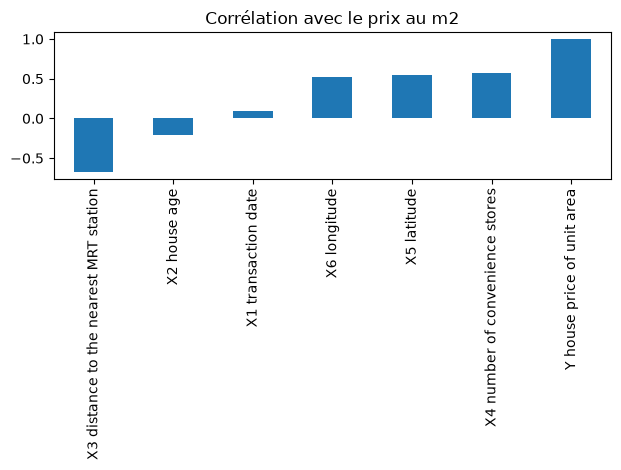

In [11]:
from ucimlrepo import fetch_ucirepo
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import numpy as np

def explore_data(df):
    print("=== Description statistique ===")
    print(df.describe())

    print("\n=== Corrélations (Pearson) ===")
    corr = df.corr(numeric_only=True)
    print(corr["Y house price of unit area"].sort_values(ascending=False))

    corr["Y house price of unit area"].sort_values().plot(kind="bar")
    plt.title("Corrélation avec le prix au m2")
    plt.tight_layout()
    plt.show



def main():

    # 1. Charger le dataset de puis UCI
    real_estate = fetch_ucirepo(id=477)

    # 2. Récupérer les features et la target
    x = real_estate.data.features
    y = real_estate.data.targets

    # 3. Combiner en un seul dataframe pour l'exploration
    df = pd.concat([x,y], axis=1)


    # 4. Exploration des données 
    
    explore_data(df)


    # 5. Split train/test

    x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42) 

    # 6. Créer et entraîner le modèle
    model = LinearRegression()
    model.fit(x_train, y_train)

    # 7. Evaluer le modele
    r2 = model.score(x_test,y_test)
    print(f"R2 sur le test : {r2}")


    coefs = np.ravel(model.coef_) # transforme (1,6) en (6,)
    print("Coefficients du modèle :")
    for name, coef in zip(x.columns, coefs):
        print(f"{name}: {coef}")

    print(f"Intercept (biais) : {model.intercept_}")


    
if __name__ == "__main__":
    main()

# Scale les features

En régression linéaire, le modèle regarde les features toutes ensemble pour ajuster ses coeffs.

Si certaines features sont sur une grande échelle et d'autres sur une petit échelle cela peut :
- Rendre l'interpretation des coeffs plus difficile
- Rendre l'optimisation numérique moins stable
- Compliquer la comparaison d'importance entre les features

## Scaling standart

le scaling standart fait deux choses pour chaque feature :
- Enlève la moyenne => centre les données autour de 0
- Divise par l'écart-type

Résultat :
- Toutes les features sont sur une échelle comparable (ordre de grandeur similaire)
- Les coeffs deviennet plus facile à comparer entre eux.


### Mise en place d'une pipeline simple avec StandartScaler

Le pattern propre avec scikit-learn est d'utiliser une pipeline

pipeline = Pipeline([
    ("scaler", StandartScaler()),
    ("model", LinearRegression())
    
    ])

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from ucimlrepo import fetch_ucirepo
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

def main():
    # 1. Charger les données
    real_estate = fetch_ucirepo(id=477)
    X = real_estate.data.features
    y = real_estate.data.targets.squeeze()  # pour avoir un vecteur 1D

    # 2. Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    # 3. Pipeline : scaler + régression linéaire
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    # 4. Entraîner le pipeline
    pipeline.fit(X_train, y_train)

    # 5. Évaluer
    r2 = pipeline.score(X_test, y_test)
    print(f"R² avec scaling : {r2}")

    # 6. Récupérer les coefficients du modèle (après scaling)
    model = pipeline.named_steps["model"]
    coefs = model.coef_
    print("Coefficients (après scaling) :")
    for name, coef in zip(X.columns, coefs):
        print(f"{name}: {coef}")

if __name__ == "__main__":
    main()

R² avec scaling : 0.6810580555095946
Coefficients (après scaling) :
X1 transaction date: 1.5296311293386944
X2 house age: -3.0626944118090975
X3 distance to the nearest MRT station: -5.786925608033049
X4 number of convenience stores: 3.2188727017566348
X5 latitude: 2.855107847927544
X6 longitude: -0.44100860256121704


# Utilisation d'un autre type de modèle pour l'entraînement des données.

Je vais utiliser un RandomForestRegressor (modèle non linéaire) il va me permettre de capturer des relations plus complexes que la simple combinaison linéaire.

Ensuite je comparerai le R2

In [1]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from ucimlrepo import fetch_ucirepo
import pandas as pd 
import matplotlib.pyplot as plt



def main():
    # 1. Charger les données
    real_estate = fetch_ucirepo(id=477)
    X = real_estate.data.features
    y = real_estate.data.targets.squeeze()  # pour avoir un vecteur 1D

    # 2. Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    # 3. Pipeline : scaler + régression linéaire
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor())
    ])

    model_non_scale = RandomForestRegressor()
    
    # 4. Entraîner le pipeline
    pipeline.fit(X_train, y_train)
    model_non_scale.fit(X_train,y_train)

    # 5. Évaluer
    r2 = pipeline.score(X_test, y_test)
    r2_non_scale = model_non_scale.score(X_test,y_test)
    print(f"R² avec scaling : {r2}")
    print(f"R2 sans scaling : {r2_non_scale}")
    print("*"*50)
    # 6. Récupérer les coefficients du modèle (après scaling)
    model = pipeline.named_steps["model"]
    coefs = model.feature_importances_
    print("Importances (après scaling) :")
    for name, coef in zip(X.columns, coefs):
        print(f"{name}: {coef}")
    print("*"*50)
    # avant scaling
    print("Importances avant scaling :")
    coefs_non_scale = model_non_scale.feature_importances_
    for name, coef in zip(X.columns,coefs_non_scale):
        print(f"{name}: {coef}")


if __name__ == "__main__":
    main()

R² avec scaling : 0.8130268787889652
R2 sans scaling : 0.8109476265872169
**************************************************
Importances (après scaling) :
X1 transaction date: 0.04289907322948494
X2 house age: 0.18201826618629557
X3 distance to the nearest MRT station: 0.5688380459738174
X4 number of convenience stores: 0.022452026323424665
X5 latitude: 0.11021837341957606
X6 longitude: 0.07357421486740148
**************************************************
Importances avant scaling :
X1 transaction date: 0.04412711340791867
X2 house age: 0.1710884390525819
X3 distance to the nearest MRT station: 0.5770666914527807
X4 number of convenience stores: 0.02269634623102727
X5 latitude: 0.11040028382865993
X6 longitude: 0.07462112602703169


# Vérification de la robustesse avec cross-validation

Le but ici est de réaliser plusieurs découpages de données et obtenir un R2 moyen.

Pour ceci, on va utiliser cross-validation (K_fold).

je vais donc garder le même code en retirant la pipeline pour la scaling car l'impact est très faible sur un modèle de RandomForestRegression

Ici, au lieu de split mon dataset avec train_test_split, j'ai utilise cross_val_score(modele, features, targets, cv=nbre_folds, scoring="r2") => J'obtiens une liste des r2 selons plusieurs folds

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from ucimlrepo import fetch_ucirepo
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt



def main():
    # 1. Charger les données
    real_estate = fetch_ucirepo(id=477)
    X = real_estate.data.features
    y = real_estate.data.targets.squeeze()  # pour avoir un vecteur 1D

    # 2. Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    # 3. Pipeline : scaler + régression linéaire

    model_non_scale = RandomForestRegressor()
    
    # 4. Entraîner le pipeline
    model_non_scale.fit(X_train,y_train)

    # 5. Évaluer
    
    r2_non_scale = model_non_scale.score(X_test,y_test)
    print(f"R2 sans scaling : {r2_non_scale}")
    print("*"*50)

    # 6. Récupérer les coefficients du modèle 
    print("Importances :")
    coefs_non_scale = model_non_scale.feature_importances_
    for name, coef in zip(X.columns,coefs_non_scale):
        print(f"{name}: {coef}")


    # 7. Verification de la robustesse avec cross-validation
    
    score = cross_val_score(model_non_scale, X, y, cv=5, scoring="r2" )
    moyenne_score = score.mean()
    ecart_type_score = np.std(score)
    print(f"K scores de cross-validation : {score}")
    print(f"Moyenne de scores : {moyenne_score}")
    print(f"écart type de K score : {ecart_type_score}")
 
if __name__ == "__main__":
    main()



R2 sans scaling : 0.8002064886797989
**************************************************
Importances :
X1 transaction date: 0.04267802416574814
X2 house age: 0.18337672217493903
X3 distance to the nearest MRT station: 0.5631798044679892
X4 number of convenience stores: 0.022230057447481126
X5 latitude: 0.1185253047345361
X6 longitude: 0.0700100870093064
K scores de cross-validation : [0.76387613 0.69049627 0.7740657  0.53634957 0.73697917]
Moyenne de scores : 0.7003533664375765
écart type de K score : 0.08695344269890788


# Dernière étape, créer le modèle de prédiction

Maintenant que j'ai testé 2 différents modèles et que j'ai explorer un peu le ML.

Je dois entrainer mon modele avec toutes les datas
Créer une fonction qui prends les valeurs des features et retourne la valeur target

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from ucimlrepo import fetch_ucirepo
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

def predict_price(feature,model):
    return model.predict(feature)

def main():
    # 1. Charger les données
    real_estate = fetch_ucirepo(id=477)
    X = real_estate.data.features
    y = real_estate.data.targets.squeeze()  # pour avoir un vecteur 1D

    display(pd.concat([X,y], axis=1))
    # 2. Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    # 3. Pipeline : scaler + régression linéaire

    model_non_scale = RandomForestRegressor()
    
    # 4. Entraîner le pipeline
    model_non_scale.fit(X_train,y_train)

    # 5. Évaluer
    
    r2_non_scale = model_non_scale.score(X_test,y_test)
    print(f"R2 sans scaling : {r2_non_scale}")
    print("*"*50)

    # 6. Récupérer les coefficients du modèle 
    print("Importances :")
    coefs_non_scale = model_non_scale.feature_importances_
    for name, coef in zip(X.columns,coefs_non_scale):
        print(f"{name}: {coef}")


    # 7. Verification de la robustesse avec cross-validation
    
    score = cross_val_score(model_non_scale, X, y, cv=5, scoring="r2" )
    moyenne_score = score.mean()
    ecart_type_score = np.std(score)
    print(f"K scores de cross-validation : {score}")
    print(f"Moyenne de scores : {moyenne_score}")
    print(f"écart type de K score : {ecart_type_score}")
 



    # 8 Creation du modele RandomForestRegressor avec toutes les données de ma dataset

    model_final = RandomForestRegressor()
    model_final.fit(X,y)

    features = np.array([[2013.5, 20, 300, 5, 24.98, 121.53]])
    
    new_prediciton = predict_price(features, model_final)
    print(new_prediciton)

if __name__ == "__main__":
    main()



,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


R2 sans scaling : 0.8033262265685586
**************************************************
Importances :
X1 transaction date: 0.04728233621661033
X2 house age: 0.17221358041763862
X3 distance to the nearest MRT station: 0.5602113947844151
X4 number of convenience stores: 0.02460400836521415
X5 latitude: 0.13087204864352417
X6 longitude: 0.06481663157259768
K scores de cross-validation : [0.76230353 0.67468999 0.76467572 0.53922277 0.70825454]
Moyenne de scores : 0.6898293101883625
écart type de K score : 0.08258996992581143
[45.6765]


c:\Users\e.vervaeren\Desktop\Learning-IOT-AI-Architect\Python\pyhton_data_science\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
